# Group 5: Edible-Oil Anomaly Screening

**Unsupervised anomaly detection with a dense autoencoder**  
Synthetic teaching dataset. Session 9: Group Deep Learning Challenge.

<a href="https://colab.research.google.com/github/khairuladib94/dl-food-research/blob/main/session-9/notebooks/05_group5_oil_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

> **Colab workflow:** Save a copy in Drive, then choose Runtime > Run all. The required teaching dataset downloads automatically; Google Drive is not mounted.



## How to work
1. Run the baseline. 2. Change one main factor in Experiment 1. 3. Change one main factor in Experiment 2. 4. Record evidence for your five-slide presentation.

In [1]:
from pathlib import Path
import os, time, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, recall_score, precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
keras.utils.set_random_seed(SEED)
# Portable workshop data setup: local Jupyter first, Colab fallback.
DATA_FILE = 'group5_oil_anomaly.npz'
LOCAL_DATA_DIR = Path('../data')
if (LOCAL_DATA_DIR / DATA_FILE).exists():
    DATA_DIR = LOCAL_DATA_DIR
    IN_COLAB = False
else:
    from urllib.request import urlretrieve
    try:
        import google.colab  # type: ignore  # noqa: F401
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False
    DATA_DIR = Path('/content/dl-food-research-data') if IN_COLAB else Path.cwd() / '.workshop-data'
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    target = DATA_DIR / DATA_FILE
    if not target.exists():
        url = 'https://raw.githubusercontent.com/khairuladib94/dl-food-research/main' + '/session-9/data/' + DATA_FILE
        print(f'Downloading {DATA_FILE} ...')
        urlretrieve(url, target)
    print(f'Dataset ready: {target}')
FIG_DIR = Path('/content/dl-food-research-figures') if IN_COLAB else Path('../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('TensorFlow:', tf.__version__, '| Keras:', keras.__version__)


TensorFlow: 2.21.0 | Keras: 3.15.0


## 1. Load and explore normal and anomalous spectra

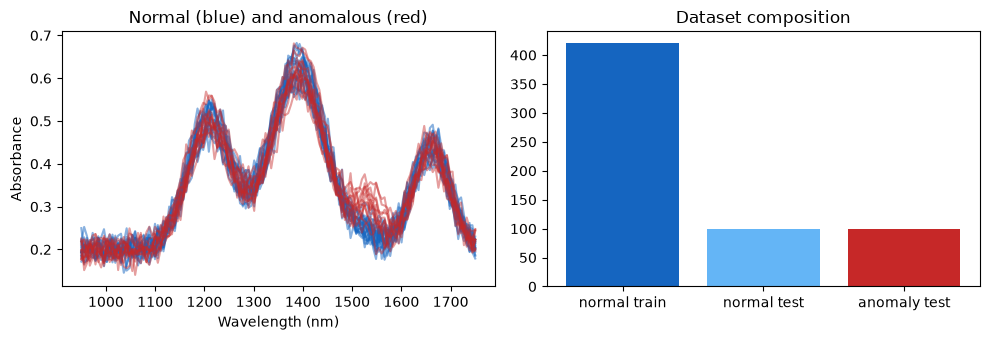

In [2]:
d=np.load(DATA_DIR/'group5_oil_anomaly.npz')
train_normal,test,y_test,w=d['train_normal'],d['test'],d['test_labels'],d['wavelength']
fig,ax=plt.subplots(1,2,figsize=(10,3.5))
for i in range(18): ax[0].plot(w,train_normal[i],alpha=.5,color='#1565c0')
for i in np.where(y_test==1)[0][:12]: ax[0].plot(w,test[i],alpha=.45,color='#c62828')
ax[0].set(title='Normal (blue) and anomalous (red)',xlabel='Wavelength (nm)',ylabel='Absorbance')
ax[1].bar(['normal train','normal test','anomaly test'],[len(train_normal),sum(y_test==0),sum(y_test==1)],color=['#1565c0','#64b5f6','#c62828'])
ax[1].set_title('Dataset composition')
plt.tight_layout(); plt.savefig(FIG_DIR/'group5_eda.png',dpi=150); plt.show()

In [3]:
X_train,X_val=train_test_split(train_normal,test_size=.20,random_state=SEED)
scaler=StandardScaler().fit(X_train)
X_train,X_val,X_test=scaler.transform(X_train),scaler.transform(X_val),scaler.transform(test)

## 2. Baseline and two controlled experiments

In [4]:
def build_ae(bottleneck=12):
    inp=keras.layers.Input((X_train.shape[1],)); x=keras.layers.Dense(48,activation='relu')(inp)
    z=keras.layers.Dense(bottleneck,activation='relu')(x); x=keras.layers.Dense(48,activation='relu')(z)
    out=keras.layers.Dense(X_train.shape[1])(x); model=keras.Model(inp,out)
    model.compile(optimizer='adam',loss='mse'); return model

def train_ae(name,bottleneck=12):
    keras.utils.set_random_seed(SEED); model=build_ae(bottleneck)
    hist=model.fit(X_train,X_train,validation_data=(X_val,X_val),epochs=18,batch_size=32,verbose=0)
    val_err=np.mean((X_val-model.predict(X_val,verbose=0))**2,axis=1)
    test_err=np.mean((X_test-model.predict(X_test,verbose=0))**2,axis=1)
    threshold=np.quantile(val_err,.99); pred=(test_err>threshold).astype(int)
    metrics={'run':name,'threshold':threshold,'precision':precision_score(y_test,pred),'recall':recall_score(y_test,pred),'F1':f1_score(y_test,pred)}
    return model,hist,test_err,metrics

baseline=train_ae('Baseline: bottleneck 12',12)
exp1=train_ae('Exp 1: bottleneck 4',4)
# Experiment 2 changes only the decision threshold of the better autoencoder.
source=max([baseline,exp1],key=lambda r:r[3]['F1'])
threshold_975=np.quantile(source[2][y_test==0],.975)
pred_975=(source[2]>threshold_975).astype(int)
exp2=(source[0],source[1],source[2],{'run':'Exp 2: 97.5% threshold','threshold':threshold_975,
      'precision':precision_score(y_test,pred_975),'recall':recall_score(y_test,pred_975),'F1':f1_score(y_test,pred_975)})
results=pd.DataFrame([baseline[3],exp1[3],exp2[3]])
display(results.round(3))

,run,threshold,precision,recall,F1
0,Baseline: bottleneck 12,0.643,0.987,0.75,0.852
1,Exp 1: bottleneck 4,0.651,0.988,0.82,0.896
2,Exp 2: 97.5% threshold,0.623,0.966,0.84,0.898


### YOUR TASK
Compare bottleneck size and threshold. Discuss the trade-off between false alarms and missed anomalies.

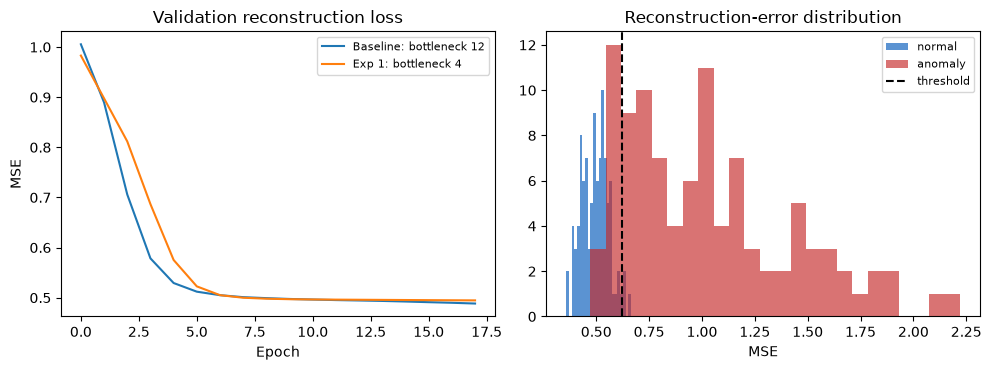

Presentation-ready summary: {'run': 'Exp 2: 97.5% threshold', 'threshold': np.float32(0.62340444), 'precision': 0.9655172413793104, 'recall': 0.84, 'F1': 0.8983957219251337}


In [5]:
best=max([baseline,exp1,exp2],key=lambda r:r[3]['F1']); threshold=best[3]['threshold']
fig,ax=plt.subplots(1,2,figsize=(10,3.8))
for r in [baseline,exp1]: ax[0].plot(r[1].history['val_loss'],label=r[3]['run'])
ax[0].set(title='Validation reconstruction loss',xlabel='Epoch',ylabel='MSE'); ax[0].legend(fontsize=8)
ax[1].hist(best[2][y_test==0],bins=24,alpha=.7,label='normal',color='#1565c0')
ax[1].hist(best[2][y_test==1],bins=24,alpha=.65,label='anomaly',color='#c62828'); ax[1].axvline(threshold,color='black',ls='--',label='threshold')
ax[1].set(title='Reconstruction-error distribution',xlabel='MSE'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/'group5_results.png',dpi=150); plt.show()
print('Presentation-ready summary:',best[3])